<a href="https://colab.research.google.com/github/Nitish-Kuma-Jha/British-Auction-in-RFQ-System/blob/main/Data_Engineering_And_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install pyspark

Total records loaded: 1600000
root
 |-- target: string (nullable = true)
 |-- ids: string (nullable = true)
 |-- date: string (nullable = true)
 |-- flag: string (nullable = true)
 |-- user: string (nullable = true)
 |-- text: string (nullable = true)

+------+----------+----------------------------+--------+---------------+--------------------------------------------------------------------------------+
|target|       ids|                        date|    flag|           user|                                                                            text|
+------+----------+----------------------------+--------+---------------+--------------------------------------------------------------------------------+
|     0|1467810369|Mon Apr 06 22:19:45 PDT 2009|NO_QUERY|_TheSpecialOne_|@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda go...|
|     0|1467810672|Mon Apr 06 22:19:49 PDT 2009|NO_QUERY|  scotthamilton|is upset that he can't update his Facebook by texting 

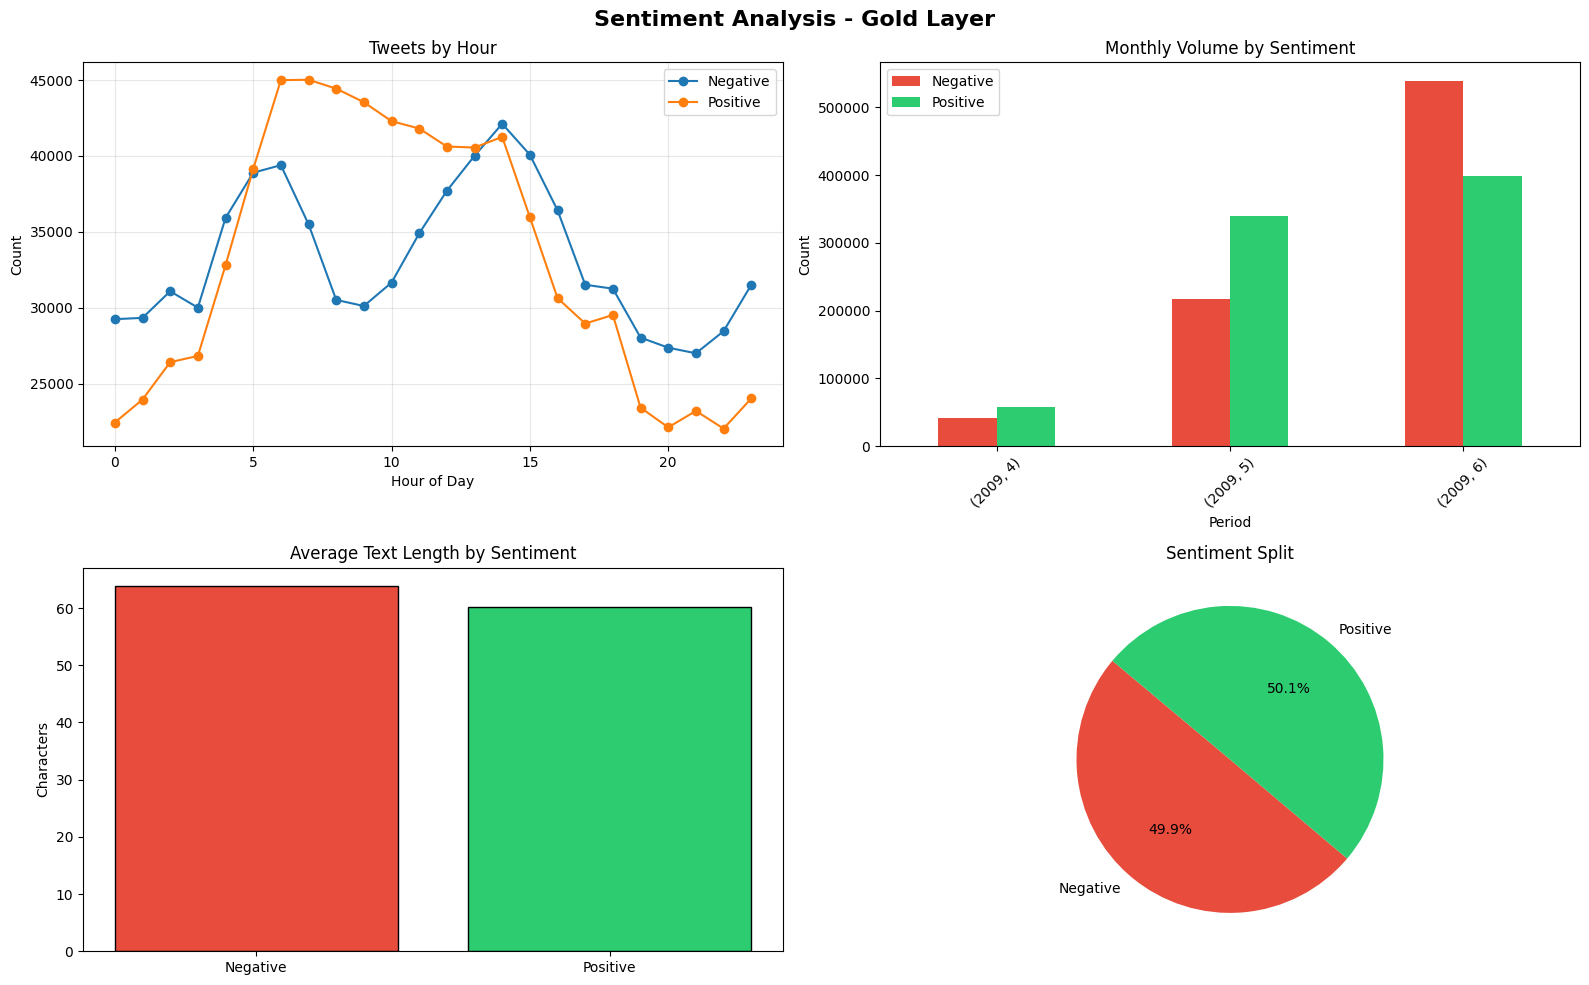

Train records: 1275629
Test records: 318258
+------------------------------------------------------------+-----+----------+-----------------------------------------+
|                                                        text|label|prediction|                              probability|
+------------------------------------------------------------+-----+----------+-----------------------------------------+
|a a kitty right outside the gym its so cute i think its a...|  0.0|       1.0|  [0.3179966021633081, 0.682003397836692]|
|             a a safe trip loving your song quotsymphonyquot|  1.0|       1.0|[0.10884567222644065, 0.8911543277735594]|
|                              a a very happy birthday to him|  1.0|       1.0|[0.15222032260093066, 0.8477796773990693]|
|a ah well at least i can sober up for a week or and possi...|  0.0|       1.0|[0.28648818859063685, 0.7135118114093632]|
|                                   a almost everyones alseep|  0.0|       1.0| [0.4160545145542104, 0

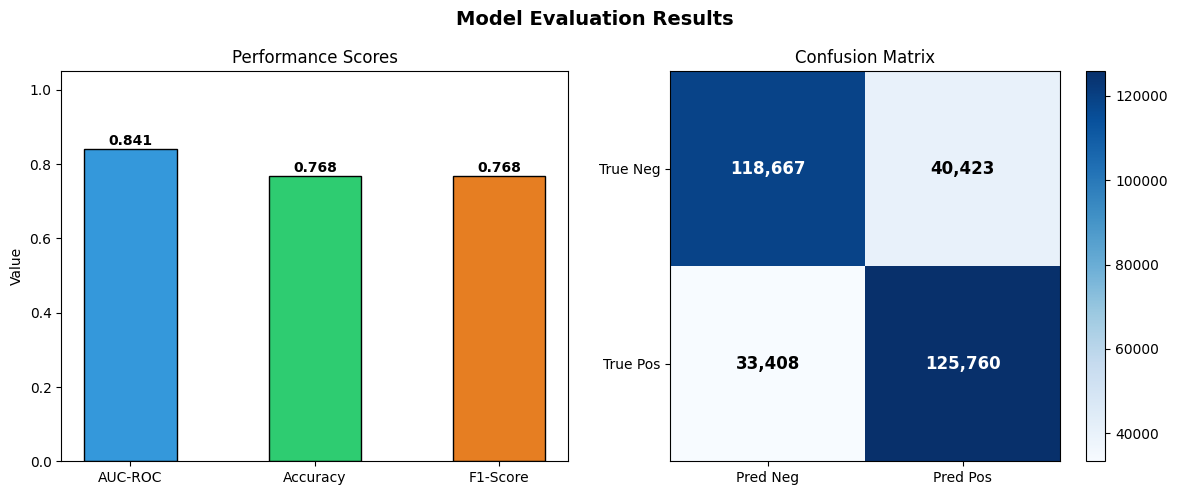

+-------------------------------------------------------+-------------------+----------------+
|                                                   text|predicted_sentiment|confidence_score|
+-------------------------------------------------------+-------------------+----------------+
|        today was such a wonderful and happy experience|           POSITIVE|           0.923|
|        terrible service and very disappointing results|           NEGATIVE|           0.042|
|   the weather outside is quite average nothing special|           NEGATIVE|            0.48|
|absolutely loved every single moment highly recommended|           POSITIVE|            0.75|
|     worst product i have ever purchased complete waste|           NEGATIVE|           0.277|
+-------------------------------------------------------+-------------------+----------------+



In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import IntegerType

from pyspark.ml import Pipeline
from pyspark.ml.feature import Tokenizer, StopWordsRemover, HashingTF, IDF
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator
from pyspark.ml.functions import vector_to_array

sprk = SparkSession.builder \
    .appName("SentimentAnalysisPipeline") \
    .config("spark.sql.shuffle.partitions", "8") \
    .config("spark.sql.legacy.timeParserPolicy", "LEGACY") \
    .getOrCreate()

sprk.sparkContext.setLogLevel("ERROR")

bronze_df = sprk.read.csv(
    "/content/CA2_dataset.csv",
    header=False,
    inferSchema=False
)

bronze_df = bronze_df.toDF("target", "ids", "date", "flag", "user", "text")

print("Total records loaded:", bronze_df.count())
bronze_df.printSchema()
bronze_df.show(5, truncate=80)

silver_df = bronze_df.dropna(subset=["text", "target"])

silver_df = silver_df \
    .withColumn("target", F.col("target").cast(IntegerType())) \
    .withColumn("ids", F.col("ids").cast("long"))

silver_df = silver_df.withColumn(
    "sentiment",
    F.when(F.col("target") == 4, 1).otherwise(0)
)

silver_df = silver_df.withColumn(
    "tweet_ts",
    F.to_timestamp(F.col("date"), "EEE MMM dd HH:mm:ss zzz yyyy")
)

silver_df = silver_df.withColumn("clean_text", F.lower(F.col("text")))

silver_df = silver_df.withColumn(
    "clean_text",
    F.regexp_replace(F.col("clean_text"), r"http\S+|www\S+", "")
)

silver_df = silver_df.withColumn(
    "clean_text",
    F.regexp_replace(F.col("clean_text"), r"@\w+", "")
)

silver_df = silver_df.withColumn(
    "clean_text",
    F.regexp_replace(F.col("clean_text"), r"#", "")
)

silver_df = silver_df.withColumn(
    "clean_text",
    F.regexp_replace(F.col("clean_text"), r"[^a-z\s]", "")
)

silver_df = silver_df.withColumn(
    "clean_text",
    F.regexp_replace(F.col("clean_text"), r"\s+", " ")
)

silver_df = silver_df.withColumn("clean_text", F.trim(F.col("clean_text")))

silver_df = silver_df.filter(F.length(F.col("clean_text")) > 2)

silver_df = silver_df.dropDuplicates(["ids"])

silver_df = silver_df \
    .withColumn("tweet_hour", F.hour(F.col("tweet_ts"))) \
    .withColumn("tweet_month", F.month(F.col("tweet_ts"))) \
    .withColumn("tweet_year", F.year(F.col("tweet_ts")))

silver_df = silver_df.withColumn("text_length", F.length(F.col("clean_text")))

silver_df = silver_df.select(
    "ids", "tweet_ts", "tweet_hour", "tweet_month", "tweet_year",
    "flag", "user", "target", "sentiment", "text", "clean_text", "text_length"
)

print("Records after cleaning:", silver_df.count())
silver_df.printSchema()
silver_df.show(5, truncate=80)

silver_df.groupBy("sentiment").count().orderBy("sentiment").show()

gold_hourly = silver_df.groupBy("tweet_hour", "sentiment") \
    .agg(
        F.count("*").alias("tweet_count"),
        F.avg("text_length").alias("avg_text_len")
    ).orderBy("tweet_hour", "sentiment")

gold_hourly.show(10)

gold_user = silver_df.groupBy("user") \
    .agg(
        F.count("*").alias("total_tweets"),
        F.sum("sentiment").alias("positive_tweets"),
        F.avg("text_length").alias("avg_text_len")
    ) \
    .withColumn(
        "positive_ratio",
        F.round(F.col("positive_tweets") / F.col("total_tweets"), 3)
    ) \
    .orderBy(F.col("total_tweets").desc())

gold_user.show(10)

gold_monthly = silver_df.groupBy("tweet_year", "tweet_month", "sentiment") \
    .agg(F.count("*").alias("tweet_count")) \
    .orderBy("tweet_year", "tweet_month", "sentiment")

gold_monthly.show(20)

gold_len_stats = silver_df.groupBy("sentiment") \
    .agg(
        F.min("text_length").alias("min_len"),
        F.max("text_length").alias("max_len"),
        F.avg("text_length").alias("avg_len"),
        F.expr("percentile_approx(text_length, 0.5)").alias("median_len")
    )

gold_len_stats.show()

hourly_pd = gold_hourly.toPandas()
monthly_pd = gold_monthly.toPandas()
len_pd = gold_len_stats.toPandas()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Sentiment Analysis - Gold Layer", fontsize=16, fontweight="bold")

for sent, grp in hourly_pd.groupby("sentiment"):
    lbl = "Positive" if sent == 1 else "Negative"
    axes[0, 0].plot(grp["tweet_hour"], grp["tweet_count"], marker="o", label=lbl)

axes[0, 0].set_title("Tweets by Hour")
axes[0, 0].set_xlabel("Hour of Day")
axes[0, 0].set_ylabel("Count")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

monthly_pivot = monthly_pd.pivot_table(
    index=["tweet_year", "tweet_month"],
    columns="sentiment",
    values="tweet_count",
    aggfunc="sum"
).fillna(0)

monthly_pivot.plot(kind="bar", ax=axes[0, 1], color=["#e74c3c", "#2ecc71"])

axes[0, 1].set_title("Monthly Volume by Sentiment")
axes[0, 1].set_xlabel("Period")
axes[0, 1].set_ylabel("Count")
axes[0, 1].legend(["Negative", "Positive"])
axes[0, 1].tick_params(axis="x", rotation=45)

bar_colors = ["#e74c3c", "#2ecc71"]

axes[1, 0].bar(
    ["Negative", "Positive"],
    len_pd.sort_values("sentiment")["avg_len"],
    color=bar_colors,
    edgecolor="black"
)

axes[1, 0].set_title("Average Text Length by Sentiment")
axes[1, 0].set_ylabel("Characters")

sent_counts = silver_df.groupBy("sentiment").count().toPandas()

axes[1, 1].pie(
    sent_counts["count"],
    labels=["Negative", "Positive"],
    autopct="%1.1f%%",
    colors=bar_colors,
    startangle=140
)

axes[1, 1].set_title("Sentiment Split")

plt.tight_layout()
plt.savefig("gold_analytics.png", dpi=150, bbox_inches="tight")
plt.show()

ml_df = silver_df.select(
    F.col("clean_text").alias("text"),
    F.col("sentiment").cast("double").alias("label")
)

train_df, test_df = ml_df.randomSplit([0.8, 0.2], seed=42)

print("Train records:", train_df.count())
print("Test records:", test_df.count())

tokenizer = Tokenizer(inputCol="text", outputCol="words")

remover = StopWordsRemover(inputCol="words", outputCol="filtered_words")

hashingTF = HashingTF(
    inputCol="filtered_words",
    outputCol="raw_features",
    numFeatures=20000
)

idf = IDF(
    inputCol="raw_features",
    outputCol="features",
    minDocFreq=5
)

lr = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    maxIter=20,
    regParam=0.01,
    elasticNetParam=0.0
)

pipeline = Pipeline(stages=[tokenizer, remover, hashingTF, idf, lr])

model = pipeline.fit(train_df)

predictions = model.transform(test_df)

predictions.select(
    "text",
    "label",
    "prediction",
    vector_to_array(F.col("probability")).alias("probability")
).show(10, truncate=60)

bin_eval = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

mc_eval_acc = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

mc_eval_f1 = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

auc = bin_eval.evaluate(predictions)
accuracy = mc_eval_acc.evaluate(predictions)
f1_score = mc_eval_f1.evaluate(predictions)

print("AUC-ROC :", round(auc, 4))
print("Accuracy:", round(accuracy, 4))
print("F1-Score:", round(f1_score, 4))

cm = predictions.groupBy("label", "prediction").count().orderBy("label", "prediction")

cm.show()

lr_model = model.stages[-1]

coefficients = lr_model.coefficients.toArray()

top20_idx = np.argsort(np.abs(coefficients))[-20:][::-1]

for rank, idx in enumerate(top20_idx, 1):
    print(f"{rank:2d}. index={idx:6d}  weight={coefficients[idx]:+.4f}")

fig2, axes2 = plt.subplots(1, 2, figsize=(12, 5))
fig2.suptitle("Model Evaluation Results", fontsize=14, fontweight="bold")

metric_vals = {
    "AUC-ROC": auc,
    "Accuracy": accuracy,
    "F1-Score": f1_score
}

metric_colors = ["#3498db", "#2ecc71", "#e67e22"]

axes2[0].bar(
    metric_vals.keys(),
    metric_vals.values(),
    color=metric_colors,
    edgecolor="black",
    width=0.5
)

axes2[0].set_ylim(0, 1.05)
axes2[0].set_title("Performance Scores")
axes2[0].set_ylabel("Value")

for i, (k, v) in enumerate(metric_vals.items()):
    axes2[0].text(i, v + 0.01, f"{v:.3f}", ha="center", fontweight="bold")

cm_pd = cm.toPandas()

cm_matrix = cm_pd.pivot(
    index="label",
    columns="prediction",
    values="count"
).fillna(0)

im = axes2[1].imshow(cm_matrix.values, cmap="Blues")

axes2[1].set_xticks([0, 1])
axes2[1].set_xticklabels(["Pred Neg", "Pred Pos"])

axes2[1].set_yticks([0, 1])
axes2[1].set_yticklabels(["True Neg", "True Pos"])

axes2[1].set_title("Confusion Matrix")

for i in range(2):
    for j in range(2):
        val = int(cm_matrix.values[i, j])
        txt_color = "white" if val > cm_matrix.values.max() / 2 else "black"

        axes2[1].text(
            j,
            i,
            f"{val:,}",
            ha="center",
            va="center",
            color=txt_color,
            fontsize=12,
            fontweight="bold"
        )

plt.colorbar(im, ax=axes2[1])

plt.tight_layout()
plt.savefig("ml_performance.png", dpi=150, bbox_inches="tight")
plt.show()

sample_tweets = sprk.createDataFrame([
    ("today was such a wonderful and happy experience",),
    ("terrible service and very disappointing results",),
    ("the weather outside is quite average nothing special",),
    ("absolutely loved every single moment highly recommended",),
    ("worst product i have ever purchased complete waste",),
], ["text"])

sample_tweets = sample_tweets.withColumn("label", F.lit(0.0))

results = model.transform(sample_tweets)

results.select(
    "text",
    F.when(F.col("prediction") == 1, "POSITIVE")
     .otherwise("NEGATIVE")
     .alias("predicted_sentiment"),
    F.round(
        vector_to_array(F.col("probability"))[1],
        3
    ).alias("confidence_score")
).show(truncate=60)

sprk.stop()